In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


In [3]:
# Reload modules to pick up changes
import importlib
import sys

# Remove cached modules
for module in list(sys.modules.keys()):
    if 'InterventionalPFN' in module or 'SimplePFN' in module:
        del sys.modules[module]

# Now import fresh (no 'src.' prefix since we're already in src/)
from models.InterventionalPFN_sklearn import InterventionalPFNSklearn
from models.GraphConditionedInterventionalPFN_sklearn import GraphConditionedInterventionalPFNSklearn
from models.SimplePFN_sklearn import SimplePFNSklearn
from sklearn.ensemble import RandomForestRegressor
from priordata_processing.BasicProcessing import BasicProcessing
import torch
from priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist


In [4]:
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/two_nodes_nograph.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16671535.0/step_100000_35.pt"

intpfn = InterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    verbose=True,  # Enable verbose mode to see what's being loaded
    max_n_train = None,
)

# Now the config should load properly with the fixed load() method
intpfn.load()

config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/two_nodes_graph.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16672273.0/step_100000.pt"

graphintpfn = GraphConditionedInterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    verbose=True,  # Enable verbose mode to see diagnostic messages
)
graphintpfn.load()


# Processor should match the config: 50 features (excluding target, including intervention column)
processor = BasicProcessing(
    n_features=2,
    max_n_features=2,
    n_train_samples = 500,
    max_n_train_samples=500,
    n_test_samples=500,
    max_n_test_samples=500,
    dropout_prob=0.0,
    target_feature = 1,
    intervened_feature=0,
    feature_standardize= True,
    shuffle_features=False,
    shuffle_samples=False,
    feature_negative_one_one_scaling=  False,
    target_negative_one_one_scaling= True,
    remove_outliers= True,
    outlier_quantile= 0.99,
    yeo_johnson= False
)



[InterventionalPFNSklearn] Loading with config_path: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/two_nodes_nograph.yaml
[InterventionalPFNSklearn] verbose=True
[InterventionalPFNSklearn] Config loaded. Top-level keys: ['experiment_name', 'description', 'mode', 'scm_config', 'dataset_config', 'preprocessing_config', 'model_config', 'training_config']
[InterventionalPFNSklearn] Loaded model_kwargs from config: {'num_features': 2, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.0, 'output_dim': 1, 'hidden_mult': 2, 'normalize_features': True, 'use_same_row_mlp': True, 'n_sample_attention_sink_rows': 10, 'n_feature_attention_sink_cols': 0}
[InterventionalPFNSklearn] BarDistribution enabled with 1000 bars
[InterventionalPFNSklearn] Model output_dim set to 1004
[InterventionalPFNSklearn] Building InterventionalPFN with kwargs: {'num_features': 2, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.0, 'out

In [131]:
# PyTorch code for the two SCMs (A: T->Y, B: Y->T) and their induced
# observational joint P(T,Y) plus interventional P(Y | do(T=t)).
#
# Requirements: torch only.

from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Tuple
import torch

Tensor = torch.Tensor


@dataclass(frozen=True)
class BivariateGaussian:
    """A tiny helper for sampling (T,Y) ~ N(0, Sigma) with std-normal marginals."""
    rho: float

    def __post_init__(self):
        if not (-1.0 < float(self.rho) < 1.0):
            raise ValueError("rho must be in (-1, 1).")

    def sample(self, n: int, device: Optional[torch.device] = None) -> Tuple[Tensor, Tensor]:
        """
        Returns:
            T: (n,) tensor
            Y: (n,) tensor
        """
        device = device or torch.device("cpu")
        eps1 = torch.randn(n, device=device)  # ~ N(0,1)
        eps2 = torch.randn(n, device=device)  # ~ N(0,1) independent
        rho = torch.tensor(self.rho, device=device, dtype=eps1.dtype)
        s = torch.sqrt(1.0 - rho * rho)

        # Construct correlated pair:
        # T = eps1
        # Y = rho*eps1 + sqrt(1-rho^2)*eps2
        T = eps1
        Y = rho * eps1 + s * eps2
        return T, Y


@dataclass(frozen=True)
class SCM_A_T_to_Y:
    """
    Model A: T -> Y
      T := e_T
      Y := rho*T + sqrt(1-rho^2)*e_Y
      P(Y|do(T)) = P(Y | T)
    """
    rho: float

    def __post_init__(self):
        if not (-1.0 < float(self.rho) < 1.0):
            raise ValueError("rho must be in (-1, 1).")

    # Observational joint P(T,Y)
    def sample_joint(self, n: int, device: Optional[torch.device] = None) -> Tuple[Tensor, Tensor]:
        return BivariateGaussian(self.rho).sample(n, device=device)

    # Interventional distribution P(Y | do(T=t))
    def sample_y_do_t(self, t: Tensor, n: Optional[int] = None) -> Tensor:
        """
        If t is scalar (0-dim or shape (1,)), you can pass n to draw n samples at that t.
        If t is a batch (shape (n,)), returns one sample per entry (ignores n).
        """
        if t.dim() == 0 or (t.dim() == 1 and t.numel() == 1):
            if n is None:
                raise ValueError("For scalar t, please provide n.")
            t = t.reshape(1).expand(n)
        else:
            if n is not None:
                raise ValueError("If t is a batch, don't pass n; you'll get one sample per t.")

        rho = torch.as_tensor(self.rho, device=t.device, dtype=t.dtype)
        s = torch.sqrt(1.0 - rho * rho)
        e_y = torch.randn_like(t)
        y = rho * t + s * e_y
        return y


@dataclass(frozen=True)
class SCM_B_Y_to_T:
    """
    Model B: Y -> T
      Y := e_Y
      T := rho*Y + sqrt(1-rho^2)*e_T
    Observationally, (T,Y) has the SAME bivariate std-normal joint as Model A.
    But intervening do(T=t) breaks the equation for T, leaving Y ~ N(0,1).
      P(Y|do(T)) = P(Y)
    """
    rho: float

    def __post_init__(self):
        if not (-1.0 < float(self.rho) < 1.0):
            raise ValueError("rho must be in (-1, 1).")

    # Observational joint P(T,Y) (same as A)
    def sample_joint(self, n: int, device: Optional[torch.device] = None) -> Tuple[Tensor, Tensor]:
        # You can generate this either via the bivariate Gaussian directly,
        # or via the structural equations (Y then T). Both give the same joint.
        device = device or torch.device("cpu")
        rho = torch.tensor(self.rho, device=device)
        s = torch.sqrt(1.0 - rho * rho)
        e_y = torch.randn(n, device=device)
        e_t = torch.randn(n, device=device)
        Y = e_y
        T = rho * Y + s * e_t
        return T, Y

    # Interventional distribution P(Y | do(T=t)) (independent of t)
    def sample_y_do_t(self, t: Tensor, n: Optional[int] = None) -> Tensor:
        """
        In Model B, Y does not depend on T, so under do(T=t): Y ~ N(0,1).
        Shape behavior matches SCM_A_T_to_Y.sample_y_do_t.
        """
        if t.dim() == 0 or (t.dim() == 1 and t.numel() == 1):
            if n is None:
                raise ValueError("For scalar t, please provide n.")
            # return n iid samples from N(0,1)
            return torch.randn(n, device=t.device, dtype=t.dtype)
        else:
            if n is not None:
                raise ValueError("If t is a batch, don't pass n; you'll get one sample per t.")
            return torch.randn_like(t)

In [132]:
# Case B: Y -> A

scm = SCM_B_Y_to_T(rho=0.99)

obs_data = scm.sample_joint(n=500)

T_obs = obs_data[0].reshape(-1,1)
Y_obs = obs_data[1].reshape(-1,1)
X_obs = torch.zeros(500,2)

T_intv = torch.linspace(-3.5, 3.5, 500).reshape(-1,1)
X_intv = torch.zeros(500,2).reshape(-1,1)
Y_intv = scm.sample_y_do_t(T_intv).reshape(-1,1)


train_data = {0: T_obs, 1: Y_obs}
test_data = {0: T_intv, 1: Y_intv}

X_obs_p, T_obs_p, Y_obs_p, X_intv_p, T_intv_p, Y_intv_p = processor.process_from_splits(
    train_data, test_data
)

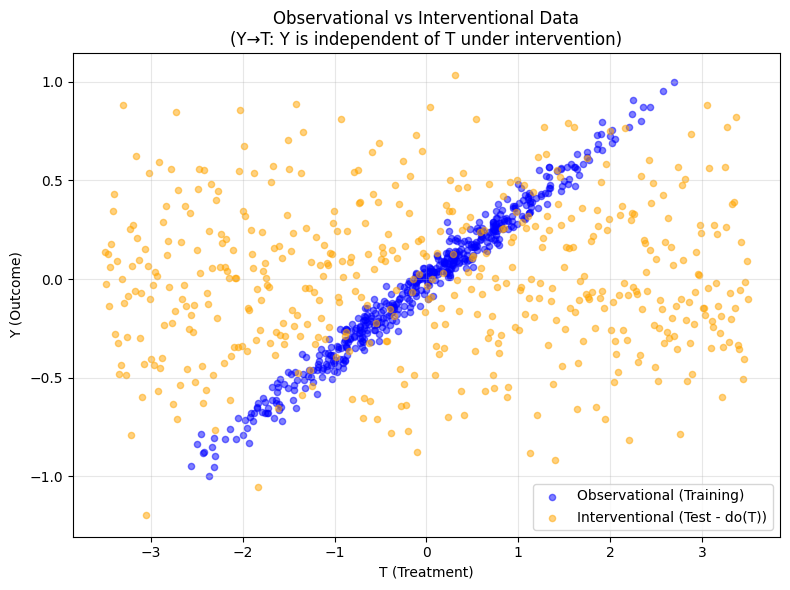

In [128]:
# Plot observational and interventional data together
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot both datasets on same axes
ax.scatter(T_obs_p.numpy().flatten(), Y_obs_p.numpy().flatten(), 
           alpha=0.5, s=20, label='Observational (Training)', color='blue')
ax.scatter(T_intv_p.numpy().flatten(), Y_intv_p.numpy().flatten(), 
           alpha=0.5, s=20, label='Interventional (Test - do(T))', color='orange')

ax.set_xlabel("T (Treatment)")
ax.set_ylabel("Y (Outcome)")
ax.set_title("Observational vs Interventional Data\n(Y→T: Y is independent of T under intervention)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
adjacency_matrix_Y_to_T = torch.tensor(
    [[0,  0, 0, 0],
     [1,  0, 0, 0],
     [0,  0, 0, 0],
     [0,  0, 0, 0],]
)

adjacency_matrix_T_to_Y = torch.tensor(
        [[0,  1, 0, 0],
        [0,  0, 0, 0],
        [0,  0, 0, 0],
        [0,  0, 0, 0],]
)

adjacency_matrix_no_edge = torch.tensor(
        [[0,  0, 0, 0],
        [0,  0, 0, 0],
        [0,  0, 0, 0],
        [0,  0, 0, 0],]
)

pred_graph = graphintpfn.predict(
        X_obs = X_obs_p.numpy(),
        T_obs = T_obs_p.numpy(),
        Y_obs = Y_obs_p.numpy(),
        X_intv = X_intv_p.numpy(),
        T_intv = T_intv_p.numpy(),
        adjacency_matrix = adjacency_matrix_Y_to_T.numpy(),
        prediction_type = "sample",    
)

pred_nograph = intpfn.predict(
        X_obs = X_obs_p.numpy(),
        T_obs = T_obs_p.numpy(),
        Y_obs = Y_obs_p.numpy(),
        X_intv = X_intv_p.numpy(),
        T_intv = T_intv_p.numpy(),
        prediction_type = "sample",
        num_samples = 1000
)

mse_graph = torch.mean((torch.tensor(pred_graph) - Y_intv_p)**2)
#mse_nograph = torch.mean((torch.tensor(pred_nograph) - Y_intv_p)**2)

print("MSE Graph-conditioned PFN:", mse_graph.item())


MSE Graph-conditioned PFN: 0.2875770926475525
MSE Non-graph PFN: 0.13102248311042786


array([-2.35782698e-01,  5.79197407e-01, -1.24258295e-01, -1.95351839e+00,
        2.28228807e-01, -2.77154036e-02, -1.22427797e+00, -7.33534694e-01,
       -6.78969473e-02, -8.65807980e-02, -3.01590282e-03, -2.40694195e-01,
        8.12921882e-01,  4.64494228e-01,  1.57038897e-01,  5.39413914e-02,
        5.44946551e-01, -1.77286482e+00,  1.26289755e-01, -4.25638743e-02,
        1.97425246e-01, -9.17623490e-02,  1.10878885e-01,  2.53499508e-01,
        2.41512150e-01, -1.83762097e+00,  5.36208272e-01, -2.45536253e-01,
       -1.87116385e-01, -1.16421103e+00, -5.41639999e-02, -2.93209106e-01,
        2.97101736e-01, -3.87071073e-01,  2.61513889e-01,  7.72786677e-01,
        3.56762797e-01,  6.90900862e-01,  5.70692345e-02,  5.64811707e-01,
       -8.56984794e-01,  9.96876508e-03,  4.06122237e-01, -6.47071078e-02,
        9.97705579e-01, -2.45589584e-01,  5.59028625e-01, -1.63862026e+00,
       -1.21813095e+00, -3.49961311e-01, -5.49028039e-01, -8.69858414e-02,
        2.90980160e-01,  

In [97]:
T_intv_p.shape
pred_nograph.shape

(1000, 500)

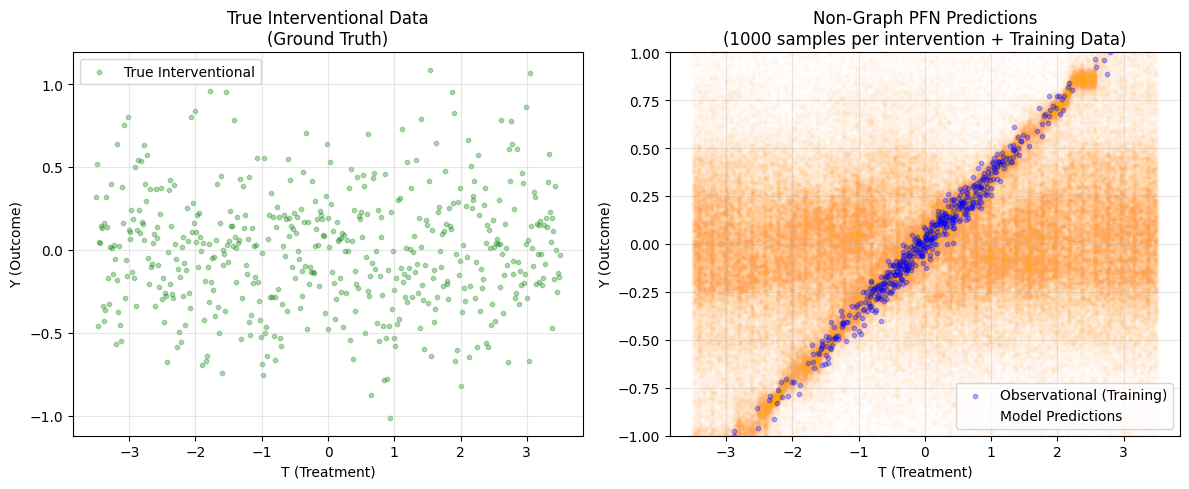

Non-graph predictions shape: (500, 500)
T_intv shape: torch.Size([500, 1])


In [115]:
# Plot predicted samples vs interventional T
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from non-graph model
pred_nograph_samples = intpfn.predict(
    X_obs = X_obs_p.numpy(),
    T_obs = T_obs_p.numpy(),
    Y_obs = Y_obs_p.numpy(),
    X_intv = X_intv_p.numpy(),
    T_intv = T_intv_p.numpy(),
    prediction_type = "sample",
    num_samples = 500
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: True interventional data
axs[0].scatter(T_intv_p.numpy().flatten(), Y_intv_p.numpy().flatten(), 
               alpha=0.3, s=10, color='green', label='True Interventional')
axs[0].set_xlabel("T (Treatment)")
axs[0].set_ylabel("Y (Outcome)")
axs[0].set_title("True Interventional Data\n(Ground Truth)")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# Plot 2: Non-graph-conditioned predictions + observational data
# First plot observational data
axs[1].scatter(T_obs_p.numpy().flatten(), Y_obs_p.numpy().flatten(),
               alpha=0.3, s=10, color='blue', label='Observational (Training)', zorder=3)

# Then plot model predictions
if pred_nograph_samples.shape[0] == 500:
    # Shape is (num_samples, n_test)
    for i in range(pred_nograph_samples.shape[1]):
        if i == 0:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[0]),
                pred_nograph_samples[:, i],
                alpha=0.01, s=5, color='orange', label='Model Predictions'
            )
        else:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[0]),
                pred_nograph_samples[:, i],
                alpha=0.01, s=5, color='orange'
            )
else:
    # Shape is (n_test, num_samples)
    for i in range(pred_nograph_samples.shape[0]):
        if i == 0:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[1]),
                pred_nograph_samples[i, :],
                alpha=0.01, s=5, color='orange', label='Model Predictions'
            )
        else:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[1]),
                pred_nograph_samples[i, :],
                alpha=0.1, s=5, color='orange'
            )
axs[1].set_xlabel("T (Treatment)")
axs[1].set_ylabel("Y (Outcome)")
axs[1].set_title("Non-Graph PFN Predictions\n(1000 samples per intervention + Training Data)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()
axs[1].set_ylim(-1,1)

plt.tight_layout()
plt.show()

print(f"Non-graph predictions shape: {pred_nograph_samples.shape}")
print(f"T_intv shape: {T_intv_p.shape}")

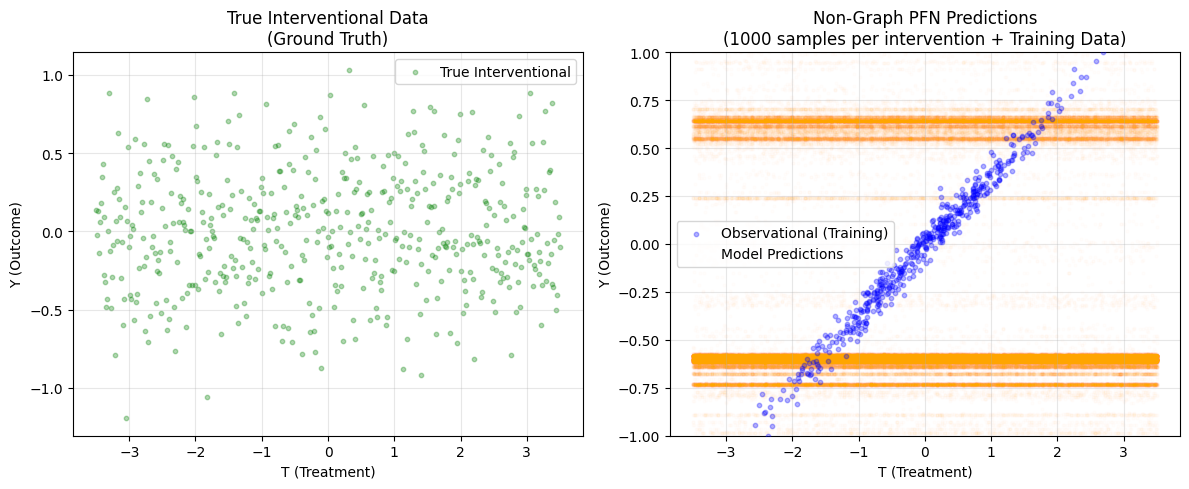

Non-graph predictions shape: (500, 500)
T_intv shape: torch.Size([500, 1])


In [130]:
# Plot predicted samples vs interventional T
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from non-graph model
pred_nograph_samples = graphintpfn.predict(
    X_obs = X_obs_p.numpy(),
    T_obs = T_obs_p.numpy(),
    Y_obs = Y_obs_p.numpy(),
    X_intv = X_intv_p.numpy(),
    T_intv = T_intv_p.numpy(),
    adjacency_matrix = adjacency_matrix_T_to_Y.numpy(),
    prediction_type = "sample",
    num_samples = 500
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: True interventional data
axs[0].scatter(T_intv_p.numpy().flatten(), Y_intv_p.numpy().flatten(), 
               alpha=0.3, s=10, color='green', label='True Interventional')
axs[0].set_xlabel("T (Treatment)")
axs[0].set_ylabel("Y (Outcome)")
axs[0].set_title("True Interventional Data\n(Ground Truth)")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# Plot 2: Non-graph-conditioned predictions + observational data
# First plot observational data
axs[1].scatter(T_obs_p.numpy().flatten(), Y_obs_p.numpy().flatten(),
               alpha=0.3, s=10, color='blue', label='Observational (Training)', zorder=3)

# Then plot model predictions
if pred_nograph_samples.shape[0] == 500:
    # Shape is (num_samples, n_test)
    for i in range(pred_nograph_samples.shape[1]):
        if i == 0:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[0]),
                pred_nograph_samples[:, i],
                alpha=0.01, s=5, color='orange', label='Model Predictions'
            )
        else:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[0]),
                pred_nograph_samples[:, i],
                alpha=0.01, s=5, color='orange'
            )
else:
    # Shape is (n_test, num_samples)
    for i in range(pred_nograph_samples.shape[0]):
        if i == 0:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[1]),
                pred_nograph_samples[i, :],
                alpha=0.01, s=5, color='orange', label='Model Predictions'
            )
        else:
            axs[1].scatter(
                np.repeat(T_intv_p.numpy().flatten()[i], pred_nograph_samples.shape[1]),
                pred_nograph_samples[i, :],
                alpha=0.1, s=5, color='orange'
            )
axs[1].set_xlabel("T (Treatment)")
axs[1].set_ylabel("Y (Outcome)")
axs[1].set_title("Non-Graph PFN Predictions\n(1000 samples per intervention + Training Data)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()
axs[1].set_ylim(-1,1)

plt.tight_layout()
plt.show()

print(f"Non-graph predictions shape: {pred_nograph_samples.shape}")
print(f"T_intv shape: {T_intv_p.shape}")

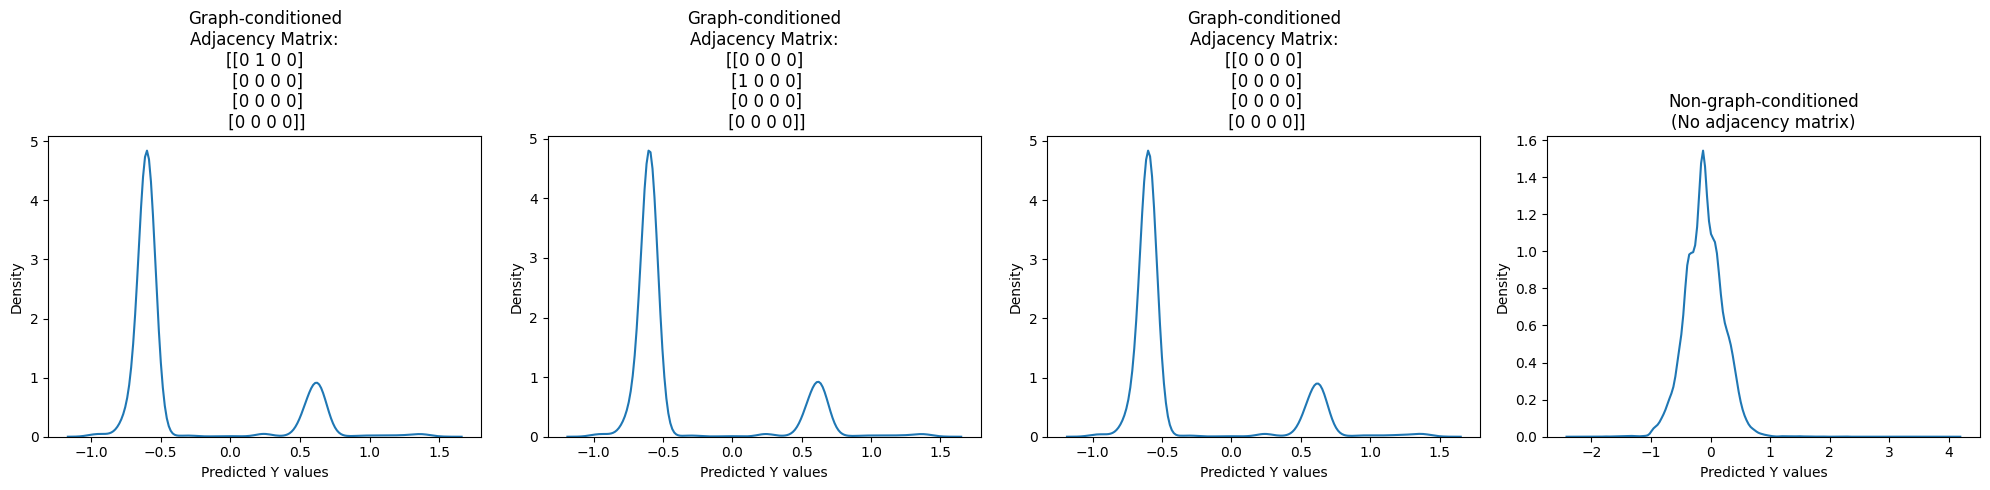

In [82]:
# plot the models predicted distribution for all three adjacency matrices + nograph model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# Graph-conditioned predictions with different adjacency matrices
for i, adj in enumerate([adjacency_matrix_T_to_Y, adjacency_matrix_Y_to_T, adjacency_matrix_no_edge]):
    pred = graphintpfn.predict(
        X_obs = X_obs_p.numpy(),
        T_obs = T_obs_p.numpy(),
        Y_obs = Y_obs_p.numpy(),
        X_intv = X_intv_p.numpy(),
        T_intv = T_intv_p.numpy(),
        adjacency_matrix = adj.numpy(),
        prediction_type = "sample",    
    )
    sns.kdeplot(pred.flatten(), ax=axs[i])
    axs[i].set_title(f"Graph-conditioned\nAdjacency Matrix:\n{adj.numpy()}")
    axs[i].set_xlabel("Predicted Y values")
    axs[i].set_ylabel("Density")

# Non-graph-conditioned prediction
pred_nograph = intpfn.predict(
    X_obs = X_obs_p.numpy(),
    T_obs = T_obs_p.numpy(),
    Y_obs = Y_obs_p.numpy(),
    X_intv = X_intv_p.numpy(),
    T_intv = T_intv_p.numpy(),
    prediction_type = "sample",
)
sns.kdeplot(pred_nograph.flatten(), ax=axs[3])
axs[3].set_title("Non-graph-conditioned\n(No adjacency matrix)")
axs[3].set_xlabel("Predicted Y values")
axs[3].set_ylabel("Density")

plt.tight_layout()
plt.show()